### Calculating the Correlation Delta Stuff

---

Get the HR of the FD Rest and Task

In [1]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable

In [2]:
def preprocess_ppg(signal, fs = 35):
    """ Computes the Preprocessed PPG Signal, this steps include the following:
        1. Moving Average Smoothing
        2. Bandpass Filtering
        
        Parameters:
        ----------
        signal (numpy array): 
            The PPG Signal to be preprocessed
        fs (float): 
            The Sampling Frequency of the Signal
            
        Returns:
        --------
        numpy array: 
            The Preprocessed PPG Signal
    
    """ 

    # Bandpass filter to isolate the cardiac component (0.4-2.5 Hz)
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs)
    filtered = scipy.signal.filtfilt(b, a, signal)

    # Standarized filtered signal
    filtered = (filtered - np.mean(filtered)) / np.std(filtered)
    
    return filtered

---
### Get Rest Scenario Signal
---

In [3]:
root_path = "UBFC-Phys"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1"]

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

face_detector_gt_rest = []
pos_face_detector_rppg_data_rest = []
lgi_face_detector_rppg_data_rest = []
omit_face_detector_rppg_data_rest = []
green_face_detector_rppg_data_rest = []
chrom_face_detector_rppg_data_rest = []

for subject in subjects:
    for task in tasks:
        # Load ground truth data
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        
        # Load rPPG data for each method
        pos_file = os.path.join(root_path, subject, f"{subject}_{task}_POS_rppg.npy")
        pos_data = np.load(pos_file)
        
        lgi_file = os.path.join(root_path, subject, f"{subject}_{task}_LGI_rppg.npy")
        lgi_data = np.load(lgi_file)

        omit_file = os.path.join(root_path, subject, f"{subject}_{task}_OMIT_rppg.npy")
        omit_data = np.load(omit_file)
        
        green_file = os.path.join(root_path, subject, f"{subject}_{task}_GREEN_rppg.npy")
        green_data = np.load(green_file)

        chrom_file = os.path.join(root_path, subject, f"{subject}_{task}_CHROM_rppg.npy")
        chrom_data = np.load(chrom_file)
        
        # Preprocess the rPPG signals
        gt_data_preprocessed = preprocess_ppg(gt_data, fs=sample_rate_gt)
        pos_data_preprocessed = preprocess_ppg(pos_data)
        lgi_data_preprocessed = preprocess_ppg(lgi_data)
        omit_data_preprocessed = preprocess_ppg(omit_data)
        green_data_preprocessed = preprocess_ppg(green_data)
        chrom_data_preprocessed = preprocess_ppg(chrom_data)
        
        # Store the data
        face_detector_gt_rest.append(gt_data_preprocessed)
        pos_face_detector_rppg_data_rest.append(pos_data_preprocessed)
        lgi_face_detector_rppg_data_rest.append(lgi_data_preprocessed)
        omit_face_detector_rppg_data_rest.append(omit_data_preprocessed)
        green_face_detector_rppg_data_rest.append(green_data_preprocessed)
        chrom_face_detector_rppg_data_rest.append(chrom_data_preprocessed)


---
### Get Task Scenario Signal
---

In [4]:
root_path = "UBFC-Phys"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T3"]

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

face_detector_gt_task = []
pos_face_detector_rppg_data_task  = []
lgi_face_detector_rppg_data_task = []
omit_face_detector_rppg_data_task = []
green_face_detector_rppg_data_task = []
chrom_face_detector_rppg_data_task = []

for subject in subjects:
    for task in tasks:
        # Load ground truth data
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        
        # Load rPPG data for each method
        pos_file = os.path.join(root_path, subject, f"{subject}_{task}_POS_rppg.npy")
        pos_data = np.load(pos_file)
        
        lgi_file = os.path.join(root_path, subject, f"{subject}_{task}_LGI_rppg.npy")
        lgi_data = np.load(lgi_file)

        omit_file = os.path.join(root_path, subject, f"{subject}_{task}_OMIT_rppg.npy")
        omit_data = np.load(omit_file)
        
        green_file = os.path.join(root_path, subject, f"{subject}_{task}_GREEN_rppg.npy")
        green_data = np.load(green_file)

        chrom_file = os.path.join(root_path, subject, f"{subject}_{task}_CHROM_rppg.npy")
        chrom_data = np.load(chrom_file)
        
        # Preprocess the rPPG signals
        gt_data_preprocessed = preprocess_ppg(gt_data, fs=sample_rate_gt)
        pos_data_preprocessed = preprocess_ppg(pos_data)
        lgi_data_preprocessed = preprocess_ppg(lgi_data)
        omit_data_preprocessed = preprocess_ppg(omit_data)
        green_data_preprocessed = preprocess_ppg(green_data)
        chrom_data_preprocessed = preprocess_ppg(chrom_data)
        
        # Store the data
        face_detector_gt_task.append(gt_data_preprocessed)
        pos_face_detector_rppg_data_task.append(pos_data_preprocessed)
        lgi_face_detector_rppg_data_task.append(lgi_data_preprocessed)
        omit_face_detector_rppg_data_task.append(omit_data_preprocessed)
        green_face_detector_rppg_data_task.append(green_data_preprocessed)
        chrom_face_detector_rppg_data_task.append(chrom_data_preprocessed)


### Calculate the HR

In [5]:
def calculate_hr(gt, rppg):
    """ Calculate the Heart Rate from the Ground Truth and rPPG Signals
    
        Parameters:
        ----------
        gt (numpy array): 
            The Ground Truth BVP Signal
        rppg (numpy array): 
            The rPPG Signal
            
        Returns:
        --------
        float: 
            The calculated Heart Rate in beats per minute (BPM)
    """

    # Calculate the peaks in the ground truth signal
    gt_peaks, _ = scipy.signal.find_peaks(gt, prominence=0.5)  
    gt_hr = int(np.mean(60 / (np.diff(gt_peaks) / sample_rate_gt)))

    # Calculate the peaks in the rPPG signal
    rppg_peaks, _ = scipy.signal.find_peaks(rppg, prominence=0.5)  
    rppg_hr = int(np.mean(60 / (np.diff(rppg_peaks) / sample_rate_video)))

    return gt_hr, rppg_hr, gt_peaks, rppg_peaks



---
### Extract the rPPG HR Rest
---

In [6]:
rppg_rest = {
    "POS" : [],
    "LGI" : [],
    "OMIT" : [],
    "GREEN" : [],
    "CHROM" : []
}

for i in range(len(face_detector_gt_rest)):
    gt_hr, pos_hr, _, _ = calculate_hr(face_detector_gt_rest[i], pos_face_detector_rppg_data_rest[i])
    gt_hr, lgi_hr, _, _ = calculate_hr(face_detector_gt_rest[i], lgi_face_detector_rppg_data_rest[i])
    gt_hr, omit_hr, _, _ = calculate_hr(face_detector_gt_rest[i], omit_face_detector_rppg_data_rest[i])
    gt_hr, green_hr, _, _ = calculate_hr(face_detector_gt_rest[i], green_face_detector_rppg_data_rest[i])
    gt_hr, chrom_hr, _, _ = calculate_hr(face_detector_gt_rest[i], chrom_face_detector_rppg_data_rest[i])

    # Append the calculated heart rates to the rPPG dictionary
    rppg_rest["POS"].append(pos_hr)
    rppg_rest["LGI"].append(lgi_hr)
    rppg_rest["OMIT"].append(omit_hr)
    rppg_rest["GREEN"].append(green_hr)
    rppg_rest["CHROM"].append(chrom_hr)

# Create a table to display the results
df_rest = pd.DataFrame({
    "Subject": [f"s{i+41}" for i in range(len(face_detector_gt_rest))],
    "GT HR (BPM)": [calculate_hr(face_detector_gt_rest[i], face_detector_gt_rest[i])[0] for i in range(len(face_detector_gt_rest))],
    "POS HR (BPM)": rppg_rest["POS"],
    "LGI HR (BPM)": rppg_rest["LGI"],
    "OMIT HR (BPM)": rppg_rest["OMIT"],
    "GREEN HR (BPM)": rppg_rest["GREEN"],
    "CHROM HR (BPM)": rppg_rest["CHROM"]
})

print("\nHeart Rate Results:")
print(df_rest)




Heart Rate Results:
   Subject  GT HR (BPM)  POS HR (BPM)  LGI HR (BPM)  OMIT HR (BPM)  \
0      s41           97            97            97             97   
1      s42           71            72            72             72   
2      s43           95            95            94             94   
3      s44           65            71            66             66   
4      s45           78            77            77             77   
5      s46           75            74            74             74   
6      s47           78            78            80             80   
7      s48           68            73            72             72   
8      s49          101           102           101            101   
9      s50          103           103           103            103   
10     s51           63            63            63             63   
11     s52           84            91            91             91   
12     s53           65            88            89             89   

---
### Extract the rPPG HR Task
---

In [7]:
rppg_task = {
    "POS" : [],
    "LGI" : [],
    "OMIT" : [],
    "GREEN" : [],
    "CHROM" : []
}

for i in range(len(face_detector_gt_task )):
    gt_hr, pos_hr, _, _ = calculate_hr(face_detector_gt_task[i], pos_face_detector_rppg_data_task[i])
    gt_hr, lgi_hr, _, _ = calculate_hr(face_detector_gt_task[i], lgi_face_detector_rppg_data_task[i])
    gt_hr, omit_hr, _, _ = calculate_hr(face_detector_gt_task[i], omit_face_detector_rppg_data_task[i])
    gt_hr, green_hr, _, _ = calculate_hr(face_detector_gt_task[i], green_face_detector_rppg_data_task[i])
    gt_hr, chrom_hr, _, _ = calculate_hr(face_detector_gt_task[i], chrom_face_detector_rppg_data_task[i])

    # Append the calculated heart rates to the rPPG dictionary
    rppg_task["POS"].append(pos_hr)
    rppg_task["LGI"].append(lgi_hr)
    rppg_task["OMIT"].append(omit_hr)
    rppg_task["GREEN"].append(green_hr)
    rppg_task["CHROM"].append(chrom_hr)

# Create a table to display the results
df_task = pd.DataFrame({
    "Subject": [f"s{i+41}" for i in range(len(face_detector_gt_task))],
    "GT HR (BPM)": [calculate_hr(face_detector_gt_task[i], face_detector_gt_task[i])[0] for i in range(len(face_detector_gt_task))],
    "POS HR (BPM)": rppg_task["POS"],
    "LGI HR (BPM)": rppg_task["LGI"],
    "OMIT HR (BPM)": rppg_task["OMIT"],
    "GREEN HR (BPM)": rppg_task["GREEN"],
    "CHROM HR (BPM)": rppg_task["CHROM"]
})

print("\nHeart Rate Results:")
print(df_task)




Heart Rate Results:
   Subject  GT HR (BPM)  POS HR (BPM)  LGI HR (BPM)  OMIT HR (BPM)  \
0      s41           82           102           100            100   
1      s42           88            94            90             90   
2      s43           88            93            90             88   
3      s44           68            71            69             69   
4      s45           85            86            82             82   
5      s46           90            88            89             90   
6      s47           87            94            89             89   
7      s48           81            86            86             85   
8      s49           78            94            92             91   
9      s50          105           105           104            104   
10     s51           74            78            75             75   
11     s52           80            89            88             88   
12     s53           74            77            75             75   

### Plot the Paired Line of the rPPG Rest vs Task HR

C:\Users\ACER\AppData\Local\Temp\ipykernel_3164\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


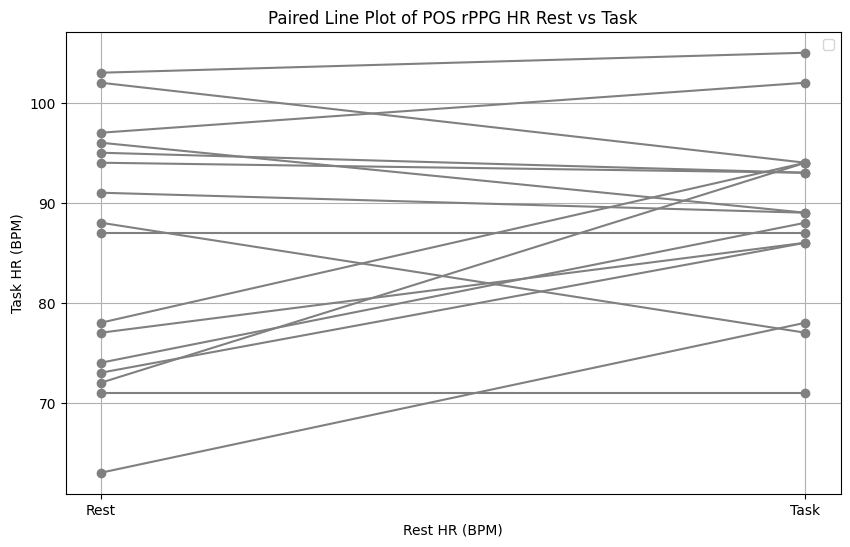

C:\Users\ACER\AppData\Local\Temp\ipykernel_3164\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


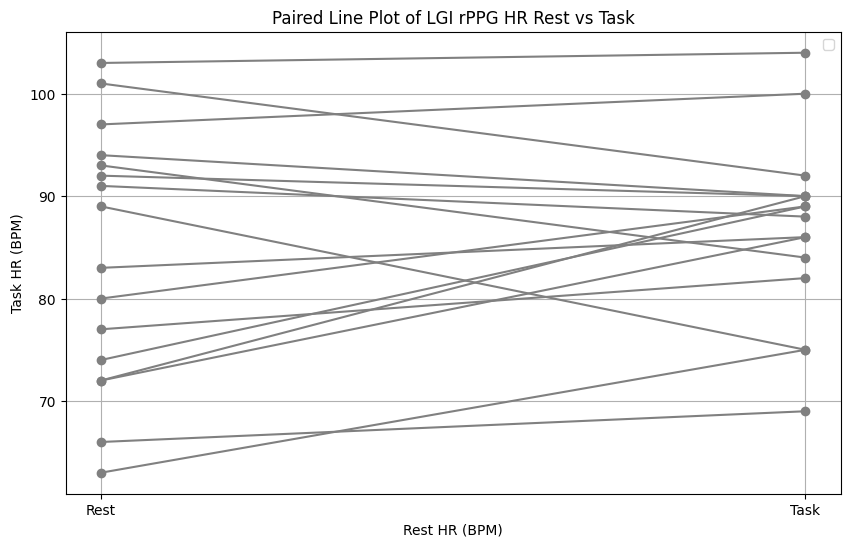

C:\Users\ACER\AppData\Local\Temp\ipykernel_3164\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


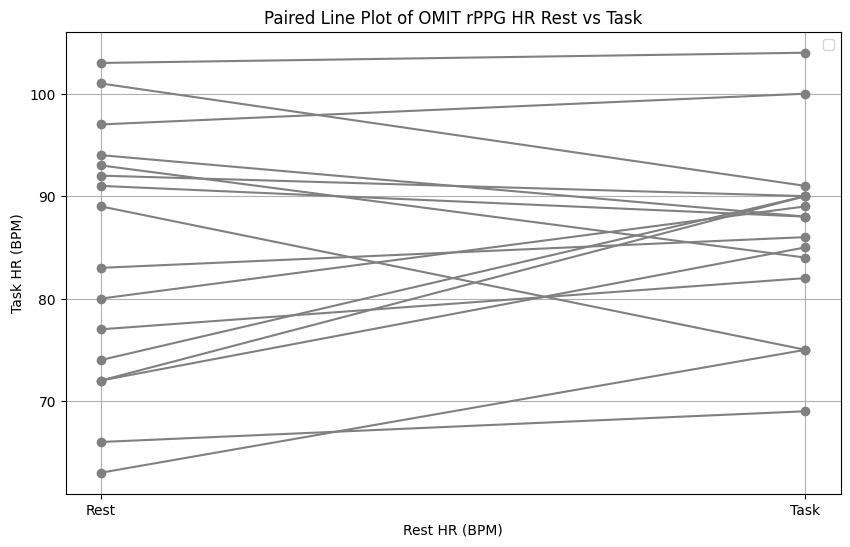

C:\Users\ACER\AppData\Local\Temp\ipykernel_3164\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


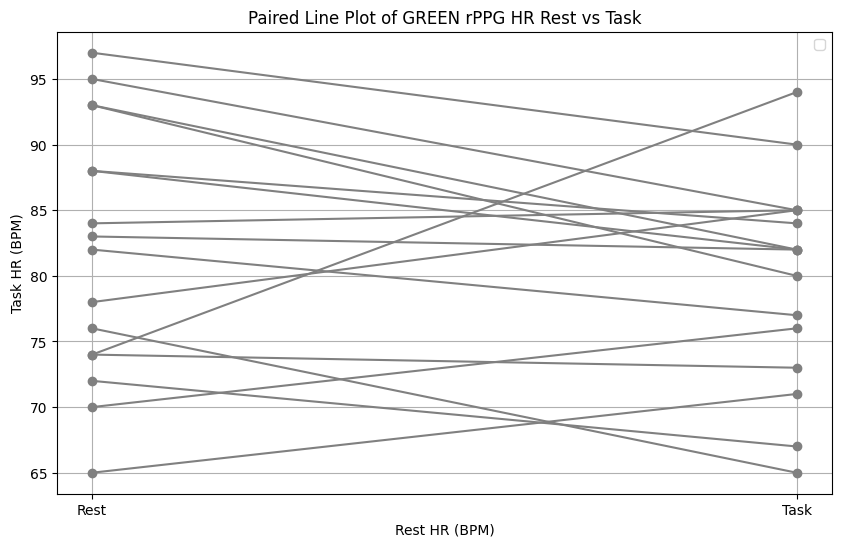

C:\Users\ACER\AppData\Local\Temp\ipykernel_3164\6292277.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


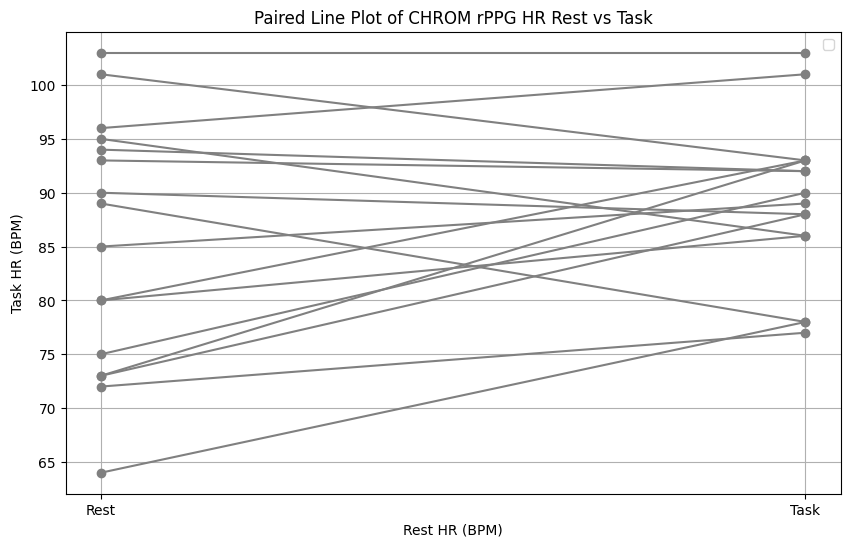

In [15]:
## Plot the paired line of the rPPG Rest vs Task HR
for method in rppg_rest.keys():
    rest = np.array(rppg_rest[method])
    task = np.array(rppg_task[method])

    plt.figure(figsize=(10, 6))
    for i in range(len(rest)):
        plt.plot([0, 1], [rest[i], task[i]], marker='o', color='gray')
    plt.title(f"Paired Line Plot of {method} rPPG HR Rest vs Task")
    plt.xlabel("Rest HR (BPM)")
    plt.ylabel("Task HR (BPM)")
    plt.xticks([0, 1], ['Rest', 'Task'])
    plt.grid()
    plt.legend()    
    plt.show()


### Plot the paired line between the GT rest and GT Task

C:\Users\ACER\AppData\Local\Temp\ipykernel_3164\2681102502.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


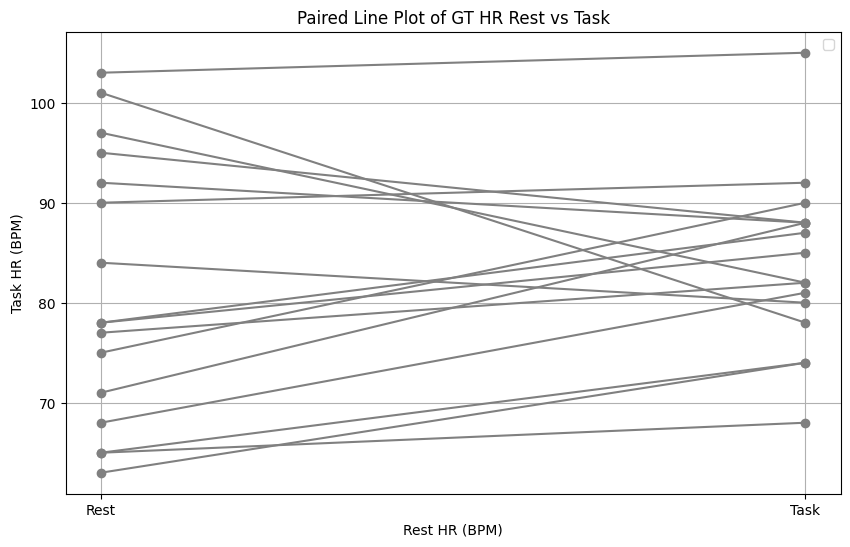

In [20]:
### Plot the paired line between the GT rest and GT Task
# Store the HR
gt_rest = np.array([calculate_hr(face_detector_gt_rest[i], face_detector_gt_rest[i])[0] for i in range(len(face_detector_gt_rest))])
gt_task = np.array([calculate_hr(face_detector_gt_task[i], face_detector_gt_task[i])[0] for i in range(len(face_detector_gt_task))])

plt.figure(figsize=(10, 6))
for i in range(len(gt_rest)):
    plt.plot([0, 1], [gt_rest[i], gt_task[i]], marker='o', color='gray')
plt.title("Paired Line Plot of GT HR Rest vs Task")
plt.xlabel("Rest HR (BPM)")
plt.ylabel("Task HR (BPM)")
plt.xticks([0, 1], ['Rest', 'Task'])
plt.grid()
plt.legend()    
plt.show()


    


### Compute the Pearson Correlation of rPPG Rest and Task compare to the PPG

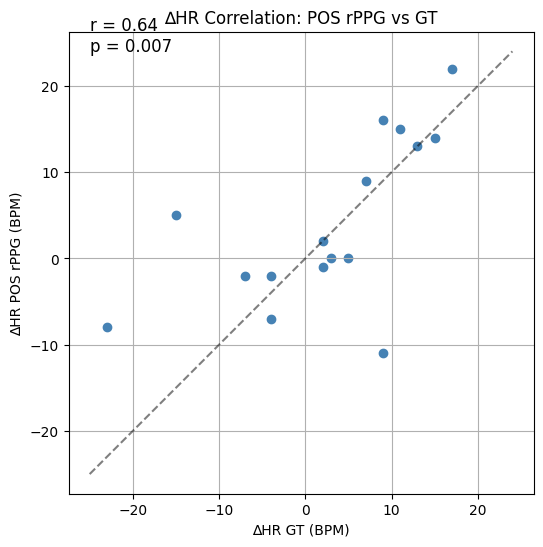

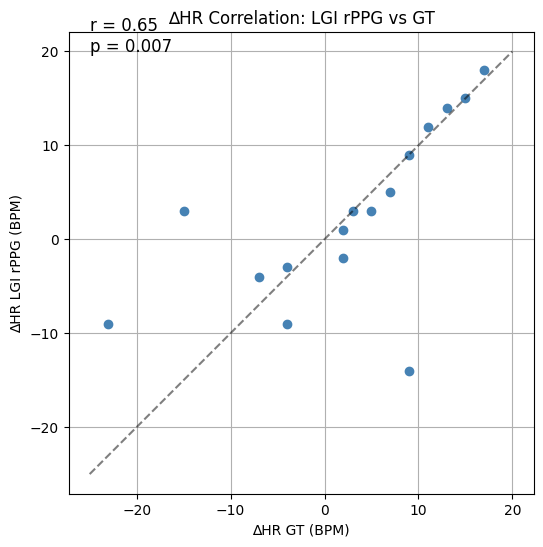

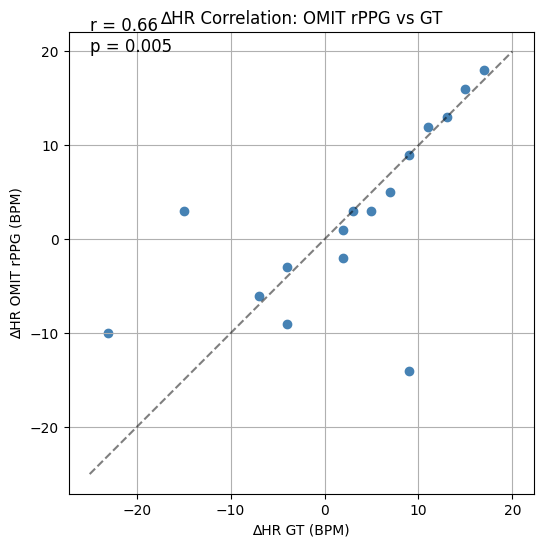

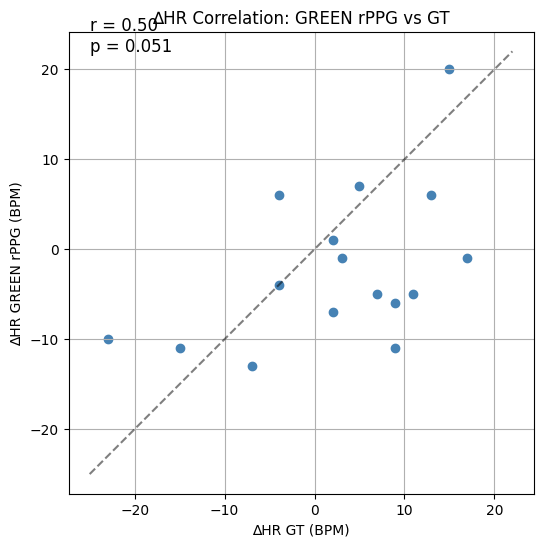

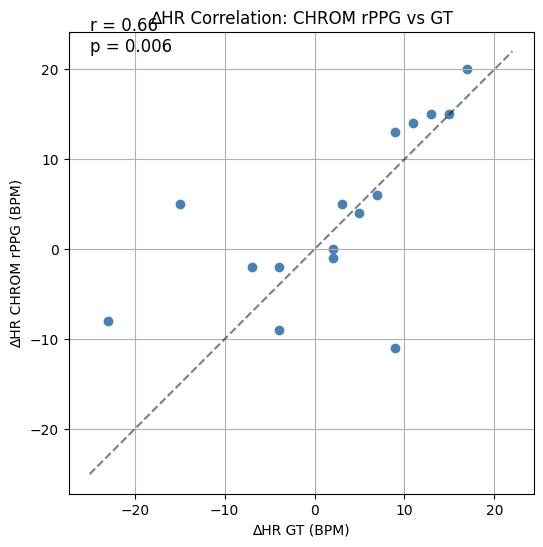

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Compute GT ∆HR per subject
delta_gt = gt_task - gt_rest  # Shape: (n_subjects,)

for method in rppg_rest.keys():
    # Get rPPG HR values for this method
    rest = np.array(rppg_rest[method])
    task = np.array(rppg_task[method])
    
    # Compute ∆HR (task - rest)
    delta_rppg = task - rest

    # Plot correlation: ∆HR_rPPG vs ∆HR_GT
    plt.figure(figsize=(6, 6))
    plt.scatter(delta_gt, delta_rppg, color='steelblue')
    
    # Identity line
    lims = [min(min(delta_gt), min(delta_rppg)) - 2,
            max(max(delta_gt), max(delta_rppg)) + 2]
    plt.plot(lims, lims, 'k--', alpha=0.5)

    # Label
    plt.title(f"∆HR Correlation: {method} rPPG vs GT")
    plt.xlabel("∆HR GT (BPM)")
    plt.ylabel(f"∆HR {method} rPPG (BPM)")
    plt.grid(True)
    plt.axis('equal')

    # Pearson correlation
    r, p = pearsonr(delta_gt, delta_rppg)
    plt.text(lims[0], lims[1], f"r = {r:.2f}\np = {p:.3f}", fontsize=12)
    
    plt.show()



In [31]:
correlation_results = {}

for method in rppg_rest.keys():
    rest = np.array(rppg_rest[method])
    task = np.array(rppg_task[method])
    delta_rppg = task - rest
    r, p = pearsonr(delta_gt, delta_rppg)
    correlation_results[method] = {'r': r, 'p': p}

# Create a DataFrame to display the correlation results
correlation_df = pd.DataFrame(correlation_results).T
correlation_df.index.name = 'Method'
correlation_df.reset_index(inplace=True)

# Display the df
print(correlation_results)

{'POS': {'r': 0.6424825355327435, 'p': 0.007276027856318536}, 'LGI': {'r': 0.648688619626454, 'p': 0.006559633238486112}, 'OMIT': {'r': 0.6644471040443656, 'p': 0.004990377418097163}, 'GREEN': {'r': 0.4961981683302438, 'p': 0.0505949825437181}, 'CHROM': {'r': 0.655338561130715, 'p': 0.005855531526271975}}


POS | ΔHR Correlation with GT: r = 0.642, p = 0.0073


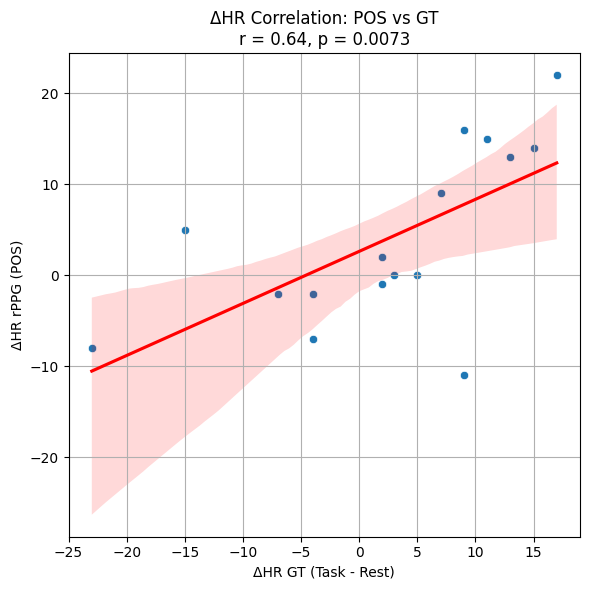

LGI | ΔHR Correlation with GT: r = 0.649, p = 0.0066


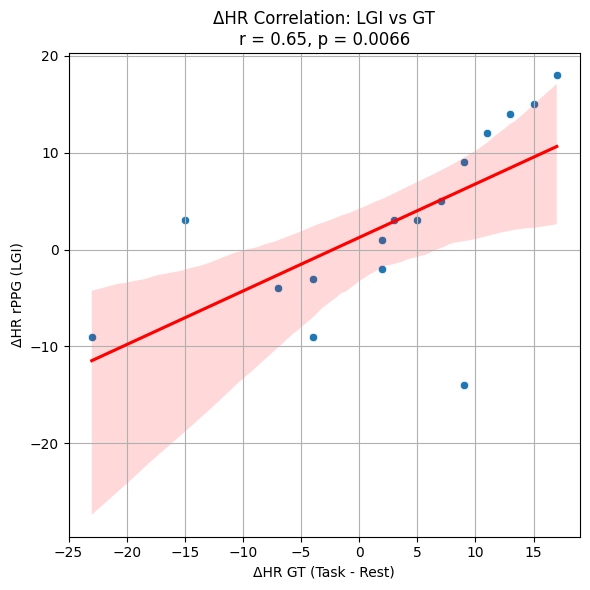

OMIT | ΔHR Correlation with GT: r = 0.664, p = 0.0050


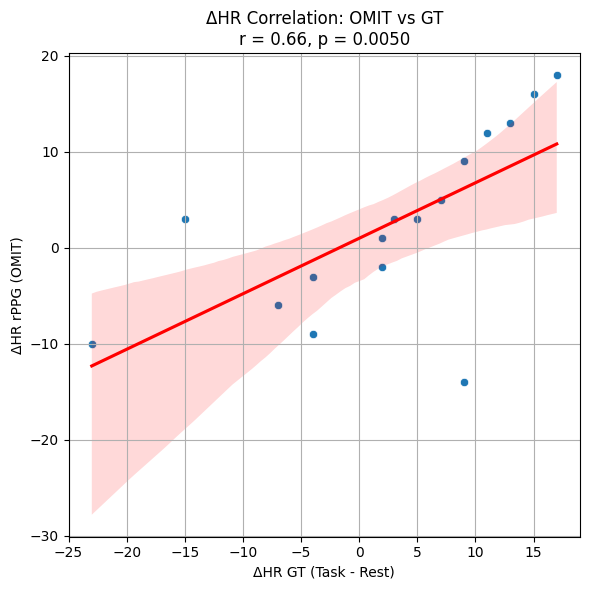

GREEN | ΔHR Correlation with GT: r = 0.496, p = 0.0506


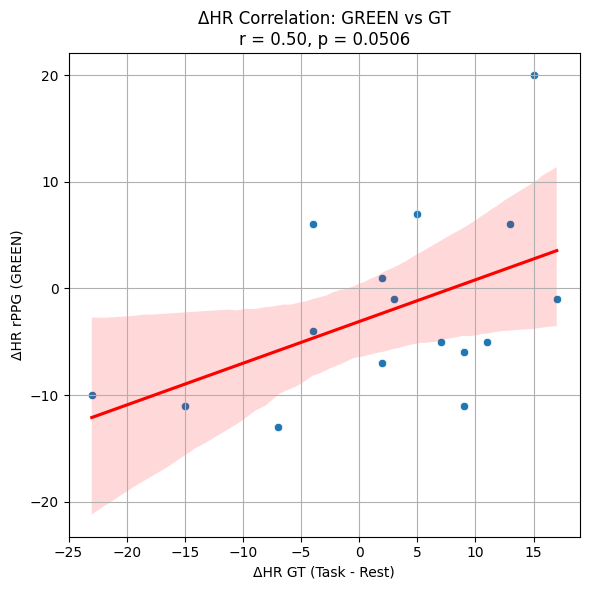

CHROM | ΔHR Correlation with GT: r = 0.655, p = 0.0059


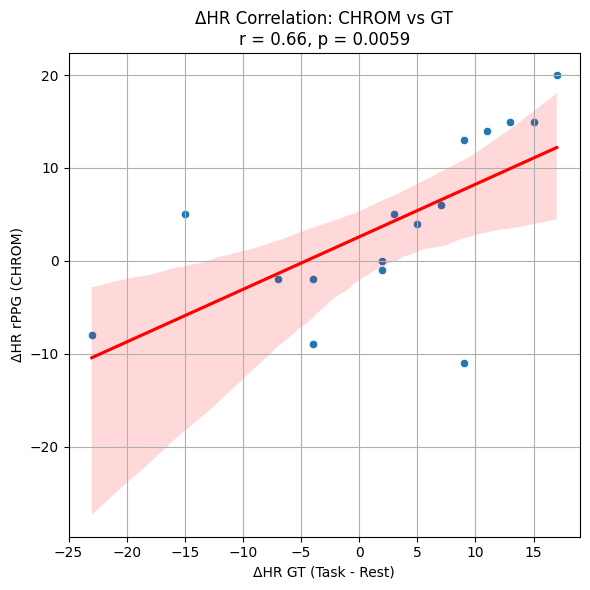

In [32]:
from scipy.stats import pearsonr
import seaborn as sns

# Delta HR GT
delta_gt = gt_task - gt_rest

for method in rppg_rest.keys():
    rest = np.array(rppg_rest[method])
    task = np.array(rppg_task[method])
    delta_rppg = task - rest

    # Compute correlation
    r, p = pearsonr(delta_gt, delta_rppg)
    print(f"{method} | ΔHR Correlation with GT: r = {r:.3f}, p = {p:.4f}")

    # Scatter plot of delta
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=delta_gt, y=delta_rppg)
    sns.regplot(x=delta_gt, y=delta_rppg, scatter=False, color='red')
    plt.xlabel('ΔHR GT (Task - Rest)')
    plt.ylabel(f'ΔHR rPPG ({method})')
    plt.title(f'ΔHR Correlation: {method} vs GT\nr = {r:.2f}, p = {p:.4f}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [33]:
for i in range(len(delta_gt)):
    print(f"Subject {i+1}: ΔGT = {delta_gt[i]:.2f}, Δ{method} = {delta_rppg[i]:.2f}")


Subject 1: ΔGT = -15.00, ΔCHROM = 5.00
Subject 2: ΔGT = 17.00, ΔCHROM = 20.00
Subject 3: ΔGT = -7.00, ΔCHROM = -2.00
Subject 4: ΔGT = 3.00, ΔCHROM = 5.00
Subject 5: ΔGT = 7.00, ΔCHROM = 6.00
Subject 6: ΔGT = 15.00, ΔCHROM = 15.00
Subject 7: ΔGT = 9.00, ΔCHROM = 13.00
Subject 8: ΔGT = 13.00, ΔCHROM = 15.00
Subject 9: ΔGT = -23.00, ΔCHROM = -8.00
Subject 10: ΔGT = 2.00, ΔCHROM = 0.00
Subject 11: ΔGT = 11.00, ΔCHROM = 14.00
Subject 12: ΔGT = -4.00, ΔCHROM = -2.00
Subject 13: ΔGT = 9.00, ΔCHROM = -11.00
Subject 14: ΔGT = 2.00, ΔCHROM = -1.00
Subject 15: ΔGT = -4.00, ΔCHROM = -9.00
Subject 16: ΔGT = 5.00, ΔCHROM = 4.00
